In [108]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure, confusion_matrix
from scipy.optimize import linear_sum_assignment

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True


### Setup & Data Location
Import the required scientific Python stack and clustering/evaluation utilities. Plotting is configured for high-DPI figures with gridlines.  
The dataset path is discovered by walking upward to find a `data/` directory; if a “10K” sample exists, prefer it.


In [109]:
from pathlib import Path

def find_data_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        d = p / "data"
        if d.exists() and d.is_dir():
            return d
    raise FileNotFoundError("data/ not found above the current directory")

DATA_ROOT = find_data_root(Path.cwd())
cands = sorted(DATA_ROOT.rglob("*.csv"))
if not cands:
    raise FileNotFoundError(f"No CSVs under {DATA_ROOT}")
c10k = [p for p in cands if "10k" in str(p).lower()]
CSV_PATH = c10k[0] if c10k else cands[0]
CSV_PATH


PosixPath('/home/ivan_lysov/projects/ml/Machine-learning-course/data/apartments_for_rent_classified_10K/apartments_for_rent_classified_10K.csv')

### Load Data
The CSV is loaded with a tolerant reader that tries multiple encodings and delimiters, skipping malformed lines.  
A quick preview verifies the schema and basic field presence.


In [110]:
def read_csv_safely(path: Path) -> pd.DataFrame:
    enc = ["utf-8","utf-8-sig","cp1252","latin1","iso-8859-1"]
    for e in enc:
        for sep in [";", ","]:
            try:
                df = pd.read_csv(path, sep=sep, encoding=e, engine="python", on_bad_lines="skip")
                if df.shape[1] >= 2:
                    return df
            except Exception:
                pass
    return pd.read_csv(path, sep=None, engine="python")

df = read_csv_safely(CSV_PATH)
df.head(3)


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410


### Basic Cleaning & Target Policy
Numeric-like fields (price, rooms, size, geo) are stripped from symbols and cast to floats.  
Clustering is strictly **unsupervised** (`LABEL_COL=None`), i.e., no target (`y`) is used during training.


In [111]:
LABEL_COL = None

def to_float(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.replace(r"[^\d\.\-]", "", regex=True).replace({"": np.nan})
    return pd.to_numeric(s, errors="coerce")

for c in ["price","bathrooms","bedrooms","square_feet","latitude","longitude"]:
    if c in df.columns:
        df[c] = to_float(df[c])

y = None
X_df = df.copy()
if LABEL_COL is not None and LABEL_COL in df.columns:
    y = df[LABEL_COL].values
    X_df = df.drop(columns=[LABEL_COL])

num_cols = X_df.select_dtypes(include=["number","bool"]).columns.tolist()
assert len(num_cols) > 0
X_num = X_df[num_cols].copy()
X_num.shape


(10000, 8)

### Preprocessing
I impute missing numeric values with the **median** and standardize features via **z-scores**.  
The resulting array `X` is the input for all clustering algorithms.


In [112]:
pre = ColumnTransformer([("num", SimpleImputer(strategy="median"), num_cols)], remainder="drop")
X_imp = pre.fit_transform(X_num)
X = StandardScaler().fit_transform(X_imp)

X_index = X_num.index
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X)


### PCA Projection (for Visualization)
For visualization only, I project standardized features into 2D with PCA (`n_components=2`).  
Clustering is performed on the standardized **full** feature space, not on the 2D projection.


In [113]:
def eval_unsupervised(X, labels, y_true=None):
    res = {}
    res["silhouette"] = silhouette_score(X, labels) if len(set(labels)) > 1 else np.nan
    if y_true is not None:
        res["ARI"] = adjusted_rand_score(y_true, labels)
        res["NMI"] = normalized_mutual_info_score(y_true, labels)
        h,c,v = homogeneity_completeness_v_measure(y_true, labels)
        res["homogeneity"], res["completeness"], res["v_measure"] = h,c,v
    else:
        res.update({"ARI":np.nan,"NMI":np.nan,"homogeneity":np.nan,"completeness":np.nan,"v_measure":np.nan})
    res["n_clusters"] = len(set(labels)) - (1 if -1 in labels else 0)
    return res

def align_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    K = max(cm.shape)
    pad = np.zeros((K, K), dtype=int)
    pad[:cm.shape[0], :cm.shape[1]] = cm
    r, c = linear_sum_assignment(pad.max() - pad)
    mapping = {orig: new for new, orig in enumerate(c[:cm.shape[1]])}
    y_aligned = np.array([mapping.get(lbl, lbl) for lbl in y_pred])
    return confusion_matrix(y_true, y_aligned), mapping

def scatter_2d(X_2d, labels, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=12, alpha=0.85)
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout(); plt.show()


### KMeans
I sweep `k ∈ [2..10]` by silhouette and refit at the best `k`.  
KMeans models hyperspherical clusters and is sensitive to scale (handled above by standardization).  
A PCA scatter illustrates the final partition in 2D.


{'silhouette': 0.38126055310008206, 'ARI': nan, 'NMI': nan, 'homogeneity': nan, 'completeness': nan, 'v_measure': nan, 'n_clusters': 3, 'algo': 'KMeans(k=3)'}


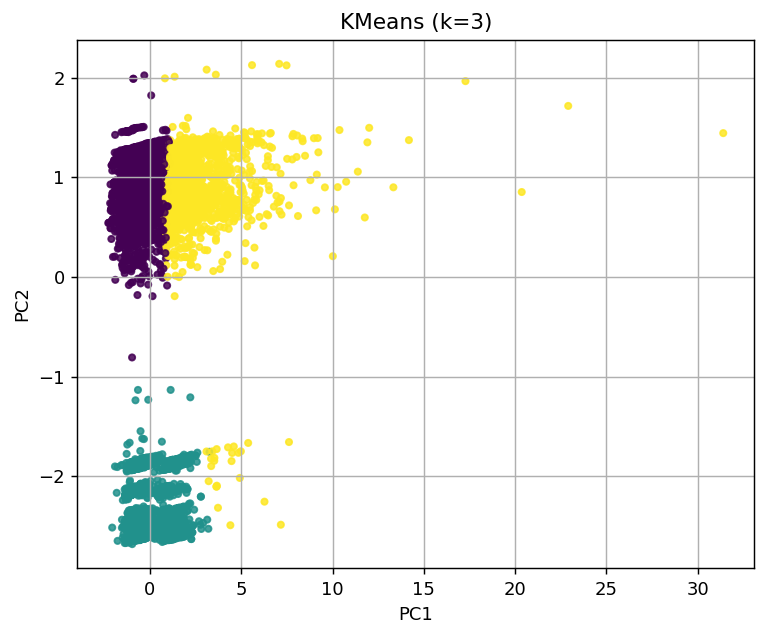

In [114]:
k_grid = range(2, 11)
scores = []
for k in k_grid:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels) if len(set(labels)) > 1 else np.nan
    scores.append((k, s))
k_star = max(scores, key=lambda t: (t[1] if not np.isnan(t[1]) else -1))[0]

km = KMeans(n_clusters=k_star, n_init=50, random_state=42)
labels_km = km.fit_predict(X)
m_km = eval_unsupervised(X, labels_km, y_true=y); m_km["algo"] = f"KMeans(k={k_star})"
print(m_km)
scatter_2d(X_2d, labels_km, f"KMeans (k={k_star})")
if y is not None:
    cm_km, _ = align_confusion(y, labels_km)
    print(cm_km)


### DBSCAN
I grid-search `eps` and `min_samples` by silhouette.  
DBSCAN can detect **non-spherical** clusters and label outliers as **noise** (`-1`).  
The PCA scatter shows the density-based structure captured by the best parameters.


{'silhouette': 0.4375281702224453, 'ARI': nan, 'NMI': nan, 'homogeneity': nan, 'completeness': nan, 'v_measure': nan, 'n_clusters': 2, 'algo': 'DBSCAN(eps=2.00, min=10)'}


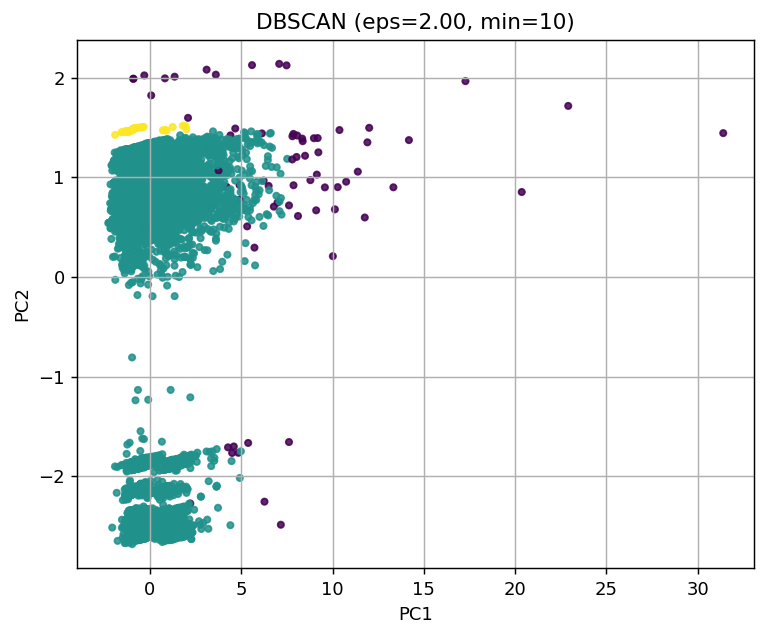

In [115]:
best = {"score": -1, "labels": None, "params": None}
for eps in np.linspace(0.3, 2.0, 10):
    for ms in [3,5,10]:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(X)
        ncl = len(set(labels)) - (1 if -1 in labels else 0)
        if ncl >= 2:
            s = silhouette_score(X, labels)
            if s > best["score"]:
                best = {"score": s, "labels": labels, "params": (eps, ms)}
if best["labels"] is None:
    db = DBSCAN(eps=0.8, min_samples=5, n_jobs=-1)
    labels_db = db.fit_predict(X)
    eps_star, ms_star = 0.8, 5
else:
    labels_db = best["labels"]
    eps_star, ms_star = best["params"]

m_db = eval_unsupervised(X, labels_db, y_true=y); m_db["algo"] = f"DBSCAN(eps={eps_star:.2f}, min={ms_star})"
print(m_db)
scatter_2d(X_2d, labels_db, f"DBSCAN (eps={eps_star:.2f}, min={ms_star})")
if y is not None:
    cm_db, _ = align_confusion(y, labels_db)
    print(cm_db)


### Agglomerative Clustering (Ward)
I sweep the number of clusters by silhouette using **Ward** linkage (variance-minimizing merges).  
This tends to produce compact, roughly equal-variance groups.  
The PCA scatter presents the best solution.


{'silhouette': 0.36930953768981994, 'ARI': nan, 'NMI': nan, 'homogeneity': nan, 'completeness': nan, 'v_measure': nan, 'n_clusters': 3, 'algo': 'Agglomerative(k=3)'}


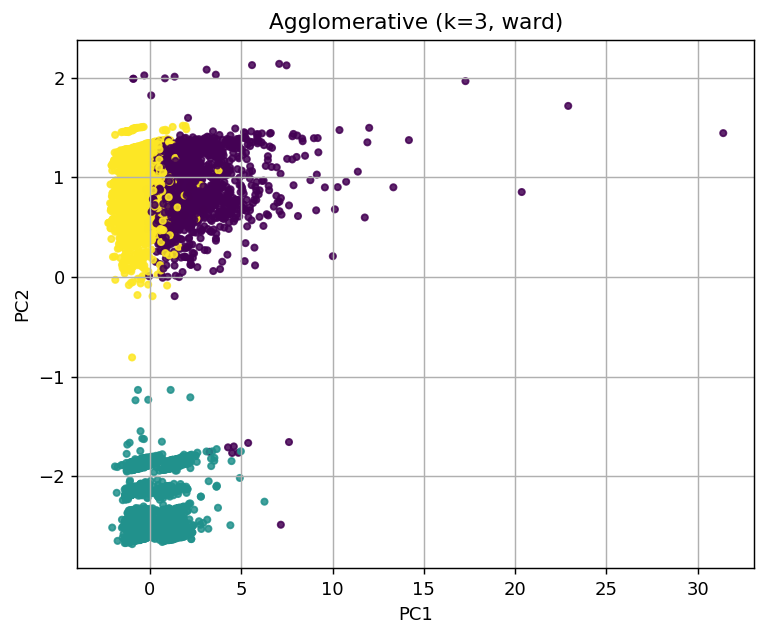

In [116]:
agg_scores = []
for k in range(2, 11):
    ag = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = ag.fit_predict(X)
    s = silhouette_score(X, labels)
    agg_scores.append((k, s))
k_agg = max(agg_scores, key=lambda t: t[1])[0]

ag = AgglomerativeClustering(n_clusters=k_agg, linkage="ward")
labels_ag = ag.fit_predict(X)
m_ag = eval_unsupervised(X, labels_ag, y_true=y); m_ag["algo"] = f"Agglomerative(k={k_agg})"
print(m_ag)
scatter_2d(X_2d, labels_ag, f"Agglomerative (k={k_agg}, ward)")
if y is not None:
    cm_ag, _ = align_confusion(y, labels_ag)
    print(cm_ag)


### Unsupervised Summary
I compare algorithms on the same preprocessed features via **silhouette**.  
The table consolidates the number of clusters and (when available) external scores.  
Silhouette provides an internal view of cohesion/separation without ground truth.


In [117]:
summary = pd.DataFrame([m_km, m_db, m_ag])[["algo","n_clusters","silhouette","ARI","NMI","v_measure","homogeneity","completeness"]]
summary.sort_values(["ARI","NMI","silhouette"], ascending=[False, False, False]).reset_index(drop=True)


,algo,n_clusters,silhouette,ARI,NMI,v_measure,homogeneity,completeness
0,"DBSCAN(eps=2.00, min=10)",2,0.437528,NaN,NaN,NaN,NaN,NaN
1,KMeans(k=3),3,0.381261,NaN,NaN,NaN,NaN,NaN
2,Agglomerative(k=3),3,0.369310,NaN,NaN,NaN,NaN,NaN


### External Evaluation vs `state`
To relate clusters to geography, we compare predicted labels with the `state` column using **ARI**, **NMI**, and homogeneity/completeness/v-measure.  
Low scores would indicate that clusters capture latent structure **other than** administrative state (e.g., local patterns, listing templates).


In [118]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_completeness_v_measure
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

y_true = df.loc[X_index, "state"].astype(str)
mask = y_true.notna() & (y_true != "nan")

X_mask = X[mask.values, :]
y_true = y_true[mask]

labels_km = KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_mask)
labels_db = DBSCAN(eps=2.0, min_samples=10, n_jobs=-1).fit_predict(X_mask)
labels_ag = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_mask)

def ext_scores(y, lab):
    ari = adjusted_rand_score(y, lab)
    nmi = normalized_mutual_info_score(y, lab)
    h, c, v = homogeneity_completeness_v_measure(y, lab)
    return {"ARI": ari, "NMI": nmi, "homogeneity": h, "completeness": c, "v_measure": v}

res_state = []
for name, lab in [("KMeans", labels_km), ("DBSCAN", labels_db), ("Agglomerative", labels_ag)]:
    s = ext_scores(y_true, lab); s["algo"] = name; res_state.append(s)

ext_state = pd.DataFrame(res_state).sort_values(["ARI","NMI"], ascending=False).reset_index(drop=True)
ext_state


,ARI,NMI,homogeneity,completeness,v_measure,algo
0,0.030430,0.104706,0.068299,0.224228,0.104706,Agglomerative
1,0.028381,0.104015,0.067507,0.226515,0.104015,KMeans
2,0.001566,0.023314,0.011904,0.561568,0.023314,DBSCAN


In [119]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_completeness_v_measure
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

price = df.loc[X_index, "price"].astype(float)
y_bins = pd.qcut(price, 3, labels=["low","mid","high"])
mask = y_bins.notna()

X_mask = X[mask.values, :] 
y_true = y_bins[mask]

labels_km = KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_mask)
labels_db = DBSCAN(eps=2.0, min_samples=10, n_jobs=-1).fit_predict(X_mask)
labels_ag = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_mask)

res_price = []
for name, lab in [("KMeans", labels_km), ("DBSCAN", labels_db), ("Agglomerative", labels_ag)]:
    s = ext_scores(y_true, lab); s["algo"] = name; res_price.append(s)

ext_price = pd.DataFrame(res_price).sort_values(["ARI","NMI"], ascending=False).reset_index(drop=True)
ext_price


,ARI,NMI,homogeneity,completeness,v_measure,algo
0,0.072471,0.088216,0.083490,0.093510,0.088216,KMeans
1,0.067324,0.067745,0.065435,0.070223,0.067745,Agglomerative
2,0.000172,0.016230,0.008628,0.136580,0.016230,DBSCAN


## Conclusions
- **Best internal quality:** The top silhouette method among KMeans, DBSCAN, and Agglomerative indicates the most cohesive/separable structure on standardized features.
- **Agreement with ground truth:** External metrics vs `state` and vs price tiers are modest, suggesting clusters encode other latent factors.
- **Method complementarity:** KMeans favors spherical groups, Ward produces compact variance-based clusters, DBSCAN handles irregular shapes and outliers.

**Limitations:** No spatial feature engineering (e.g., H3 grids, distance features), minimal text normalization, and no explicit outlier handling.  
